# Ethiopian Grade 12 Exam Pattern Project (Google Colab)

This notebook converts your scripts into a Colab workflow:
1. Download Grade 12 exam PDFs
2. OCR text extraction from PDFs
3. Build a simple question-pattern analysis baseline


## Notes
- Run cells top to bottom.
- In Colab, OCR dependencies are installed automatically.
- Data is saved under `/content/ethiopian_exam_project`.

## Mount Google Drive

To save files directly to your Google Drive and ensure persistence across sessions, we will mount Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Update Project Root

I will now update the `PROJECT_ROOT` to a location within your Google Drive. This change ensures that all subsequent operations (downloading PDFs, extracting text, and saving CSVs) will use your Drive as the storage location, preventing repeated downloads and OCR processing.

In [2]:
!apt-get update -qq
!apt-get install -y -qq poppler-utils tesseract-ocr

import torch
import subprocess
import sys

has_gpu = torch.cuda.is_available()
if has_gpu:
    print("GPU detected! Installing onnxruntime-gpu for fast RapidOCR inference...")
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "onnxruntime"], capture_output=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxruntime-gpu"])
else:
    print("No GPU detected. RapidOCR will run on CPU.")

!pip -q install pandas scikit-learn matplotlib seaborn easyocr rapidocr_onnxruntime PyPDF2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package poppler-utils.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
GPU detected! Installing onnxruntime-gpu for fast RapidOCR inference...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.9 MB/s eta 0:0

In [3]:
import os
import re
import csv
import time
import tempfile
import subprocess
import urllib.request
from collections import Counter, defaultdict
import pandas as pd

BASE_URL = "https://www.ethiobookreview.com/assets/exams/"
PROJECT_ROOT = "/content/drive/MyDrive/ethiopian_exam_project" # Updated to Google Drive path
DOWNLOAD_DIR = os.path.join(PROJECT_ROOT, "downloads")
EXTRACTED_DIR = os.path.join(PROJECT_ROOT, "extracted_text")
TEXTBOOK_EXTRACTED_DIR = os.path.join(PROJECT_ROOT, "textbook_extracted_text") # New directory for extracted textbook text
OUTPUT_CSV = os.path.join(PROJECT_ROOT, "ethiopian_exams_extracted.csv")
PATTERN_CSV = os.path.join(PROJECT_ROOT, "pattern_summary.csv")

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(EXTRACTED_DIR, exist_ok=True)
os.makedirs(TEXTBOOK_EXTRACTED_DIR, exist_ok=True) # Ensure the new directory exists

NATURAL_SCIENCE_SUBJECTS = ["english","mathematics","physics","chemistry","biology","civics"]
YEARS = ["2005", "2006", "2007", "2008", "2009", "2010"]
TYPES = ["questions", "answers"]


In [4]:
import ssl

def download_file(url, filepath, max_retries=3):
    # Create an unverified SSL context to bypass certificate issues
    ssl._create_default_https_context = ssl._create_unverified_context

    # Add User-Agent header to mimic a web browser
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    req = urllib.request.Request(url, headers=headers)

    for attempt in range(max_retries):
        try:
            with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
                out_file.write(response.read())
            return True
        except Exception as e:
            print(f"Attempt {attempt+1} failed for {os.path.basename(filepath)}: {e}")
            time.sleep(2)
    return False

def download_subject_year(subject, year, target_dir):
    results = []
    for file_type in TYPES:
        filename = f"{subject}-{year}-{file_type}.pdf"
        url = f"{BASE_URL}{filename}"
        filepath = os.path.join(target_dir, filename)

        if os.path.exists(filepath):
            results.append((filename, "already_downloaded"))
            continue

        ok = download_file(url, filepath)
        results.append((filename, "success" if ok else "failed"))
        time.sleep(0.5)
    return results

def run_downloader():
    all_subjects = {"natural_science": NATURAL_SCIENCE_SUBJECTS}
    summary = defaultdict(lambda: {"downloaded": 0, "failed": 0, "already": 0})

    for stream, subjects in all_subjects.items():
        for subject in subjects:
            subject_dir = os.path.join(DOWNLOAD_DIR, stream, subject)
            os.makedirs(subject_dir, exist_ok=True)
            for year in YEARS:
                for _, status in download_subject_year(subject, year, subject_dir):
                    if status == "success": summary[subject]["downloaded"] += 1
                    elif status == "failed": summary[subject]["failed"] += 1
                    else: summary[subject]["already"] += 1

    return pd.DataFrame(summary).T.sort_index()

download_report = run_downloader()
download_report

,downloaded,failed,already
biology,0,0,12
chemistry,0,0,12
civics,0,0,12
english,0,0,12
mathematics,0,0,12
physics,0,0,12


In [5]:
import os
os.environ['OMP_THREAD_LIMIT'] = '1'

try:
    from rapidocr_onnxruntime import RapidOCR
    _OCR_BACKEND = 'rapidocr'
    _rapidocr_reader = RapidOCR()
except Exception as _e:
    print(f'RapidOCR unavailable ({_e}); trying EasyOCR.')
    try:
        import easyocr
        _OCR_BACKEND = 'easyocr'
        _easyocr_reader = easyocr.Reader(['en'], gpu=True)
    except Exception as _e2:
        print(f'EasyOCR unavailable ({_e2}); falling back to Tesseract.')
        _OCR_BACKEND = 'tesseract'
        _easyocr_reader = None

from concurrent.futures import ThreadPoolExecutor

def pdf_to_images(pdf_path, output_dir, dpi=150):
    cmd = ['pdftoppm', '-r', str(dpi), '-png', pdf_path, os.path.join(output_dir, 'page')]
    subprocess.run(cmd, capture_output=True, check=False)
    images = sorted([f for f in os.listdir(output_dir) if f.startswith('page') and f.endswith('.png')])
    return [os.path.join(output_dir, img) for img in images]

def extract_text_from_image(image_path, min_confidence=0.3):
    if _OCR_BACKEND == 'rapidocr':
        results, _ = _rapidocr_reader(image_path)
        if not results:
            return '', 0.0
        pieces = []
        confs = []
        for _, text, conf in results:
            if text.strip():
                pieces.append(text)
                confs.append(float(conf))
        text = ' '.join(pieces)
        mean_conf = sum(confs) / len(confs) if confs else 0.0
        return text, mean_conf
    elif _OCR_BACKEND == 'easyocr':
        results = _easyocr_reader.readtext(image_path, detail=1, paragraph=False)
        pieces, confs = [], []
        for _, txt, conf in results:
            if conf >= min_confidence and txt.strip():
                pieces.append(txt)
                confs.append(conf)
        text = ' '.join(pieces)
        mean_conf = sum(confs) / len(confs) if confs else 0.0
        return text, mean_conf
    cmd = ['tesseract', image_path, 'stdout', '-l', 'eng', '--psm', '6']
    result = subprocess.run(cmd, capture_output=True, text=True)
    text = result.stdout if result.returncode == 0 else ''
    return text, (0.6 if text.strip() else 0.0)

def clean_text(text):
    return re.sub(r'\s+', ' ', text).strip() if text else ''

_WEB_HEADER_RE = re.compile(
    r'\d{1,2}/\d{1,2}/\d{2,4},?\s*\d{1,2}:\d{2}\s*[AP]M\s+'
    r'(?:National\s+Examinations\s+)?',
    re.IGNORECASE,
)

def strip_web_header(text):
    """Drop the 'M/D/YY, H:MM PM National Examinations' prefix added by the
    browser print-to-PDF flow that produced the source files. Repeats may
    appear once per page after concatenation, so we strip globally."""
    if not text:
        return text
    return _WEB_HEADER_RE.sub(' ', text).strip()

def parse_filename(filename):
    parts = filename.replace('.pdf', '').split('-')
    subject = parts[0] if len(parts) > 0 else 'unknown'
    year = parts[1] if len(parts) > 1 else 'unknown'
    ftype = parts[2] if len(parts) > 2 else 'unknown'
    return subject, year, ftype

def extract_all_pdfs():
    all_records = []
    natural_subjects = set(NATURAL_SCIENCE_SUBJECTS)

    pdf_paths = []
    for root, _, files in os.walk(DOWNLOAD_DIR):
        pdf_paths += [os.path.join(root, f) for f in files if f.endswith('.pdf')]

    # Sort for consistent processing order and progress reporting
    pdf_paths.sort()

    for i, pdf_path in enumerate(pdf_paths, 1):
        filename = os.path.basename(pdf_path)
        subject, year, ftype = parse_filename(filename)
        stream = 'natural_science' if subject in natural_subjects else 'unknown'

        subject_dir = os.path.join(EXTRACTED_DIR, stream, subject)
        os.makedirs(subject_dir, exist_ok=True)
        txt_path = os.path.join(subject_dir, filename.replace('.pdf', '.txt'))

        text_full = ''
        mean_conf = 0.0
        ocr_engine_used = _OCR_BACKEND

        if os.path.exists(txt_path):
            # Load from cached text file if it exists
            with open(txt_path, 'r', encoding='utf-8') as f:
                text_full = f.read()
            text_full = strip_web_header(text_full)
            mean_conf = 1.0 # Indicate high confidence for cached content
            ocr_engine_used = 'cached'
            print(f'({i}/{len(pdf_paths)}) Loaded text for {filename} from cache.')
        else:
            # Perform OCR if text file does not exist
            temp_dir = tempfile.mkdtemp(prefix='pdf_ocr_') # Create temp dir for each PDF
            try:
                images = pdf_to_images(pdf_path, temp_dir, dpi=150)

                def process_page(args):
                    idx, img = args
                    try:
                        t, c = extract_text_from_image(img)
                        return idx, t, c
                    finally:
                        try:
                            os.remove(img)
                        except OSError:
                            pass

                max_workers = min(len(images), os.cpu_count() or 4)
                if max_workers > 1:
                    with ThreadPoolExecutor(max_workers=max_workers) as executor:
                        pages_res = list(executor.map(process_page, enumerate(images)))
                else:
                    pages_res = [process_page((idx, img)) for idx, img in enumerate(images)]

                pages_res = sorted(pages_res, key=lambda x: x[0])
                page_texts = [p[1] for p in pages_res]
                page_confs = [p[2] for p in pages_res]

                text_full = strip_web_header(clean_text('\n\n'.join(page_texts)))
                mean_conf = sum(page_confs) / len(page_confs) if page_confs else 0.0

                with open(txt_path, 'w', encoding='utf-8') as f:
                    f.write(text_full)

                if i % 10 == 0:
                    print(f'({i}/{len(pdf_paths)}) Processed and saved OCR for {filename}')
            finally:
                # Clean up the temporary directory after processing each PDF
                for f in os.listdir(temp_dir):
                    fp = os.path.join(temp_dir, f)
                    if os.path.isfile(fp):
                        os.remove(fp)
                os.rmdir(temp_dir)

        all_records.append({
            'subject': subject,
            'year': year,
            'type': ftype,
            'stream': stream,
            'filename': filename,
            'text_length': len(text_full),
            'ocr_engine': ocr_engine_used,
            'ocr_confidence': round(mean_conf, 3),
            'text_preview': text_full[:500],
            'text_full': text_full
        })

    df = pd.DataFrame(all_records)
    df.to_csv(OUTPUT_CSV, index=False)
    return df

exams_df = extract_all_pdfs()
exams_df.head()

(1/72) Loaded text for biology-2005-answers.pdf from cache.
(2/72) Loaded text for biology-2005-questions.pdf from cache.
(3/72) Loaded text for biology-2006-answers.pdf from cache.
(4/72) Loaded text for biology-2006-questions.pdf from cache.
(5/72) Loaded text for biology-2007-answers.pdf from cache.
(6/72) Loaded text for biology-2007-questions.pdf from cache.
(7/72) Loaded text for biology-2008-answers.pdf from cache.
(8/72) Loaded text for biology-2008-questions.pdf from cache.
(9/72) Loaded text for biology-2009-answers.pdf from cache.
(10/72) Loaded text for biology-2009-questions.pdf from cache.
(11/72) Loaded text for biology-2010-answers.pdf from cache.
(12/72) Loaded text for biology-2010-questions.pdf from cache.
(13/72) Loaded text for chemistry-2005-answers.pdf from cache.
(14/72) Loaded text for chemistry-2005-questions.pdf from cache.
(15/72) Loaded text for chemistry-2006-answers.pdf from cache.
(16/72) Loaded text for chemistry-2006-questions.pdf from cache.
(17/72) L

,subject,year,type,stream,filename,text_length,ocr_engine,ocr_confidence,text_preview,text_full
0,biology,2005,answers,natural_science,biology-2005-answers.pdf,22971,cached,1.0,"4/18/25, 5:06 PM National Examinations NATIONA...","4/18/25, 5:06 PM National Examinations NATIONA..."
1,biology,2005,questions,natural_science,biology-2005-questions.pdf,20753,cached,1.0,"4/18/25,5:05 PM National Examinations NATIONAL...","4/18/25,5:05 PM National Examinations NATIONAL..."
2,biology,2006,answers,natural_science,biology-2006-answers.pdf,22227,cached,1.0,"4/18/25,5:07 PM National Examinations NATIONAL...","4/18/25,5:07 PM National Examinations NATIONAL..."
3,biology,2006,questions,natural_science,biology-2006-questions.pdf,19789,cached,1.0,"4/18/25,5:06 PM National Examinations NATIONAL...","4/18/25,5:06 PM National Examinations NATIONAL..."
4,biology,2007,answers,natural_science,biology-2007-answers.pdf,23970,cached,1.0,"4/18/25, 5:09 PM National Examinations NATIONA...","4/18/25, 5:09 PM National Examinations NATIONA..."


## Question extraction & topic taxonomy

Replaces the old keyword-only approach with:
1. **Question extraction** — split each exam's OCR text into individual questions (with options), so trend analysis runs on actual question stems, not the full document (which mixes instructions, page numbers, and OCR noise).
2. **Hybrid TF-IDF taxonomy** — start from hand-curated `TOPIC_RULES` (in `topics.py`) and augment each topic's keyword set with terms learned from the corpus that statistically co-occur with seed keywords. Catches synonyms and related vocabulary that pure keyword matching misses.

In [7]:
# Use the project modules for question parsing + taxonomy.
# In Colab, make sure the repo files are on sys.path:
import sys
_repo_dir = os.getcwd()
if _repo_dir not in sys.path:
    sys.path.insert(0, _repo_dir)

from question_extractor import extract_questions, extract_question_texts
from topic_classifier import build_taxonomy, score_text
from topics import TOPIC_RULES

def clean_question_text(raw):
    """Lightweight noise removal kept for backward compatibility with cell-12."""
    if not isinstance(raw, str):
        return ''
    t = re.sub(r'[_~`|\\]+', ' ', raw)
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'(?<![A-Za-z])[A-Da-d][\)\.:/](?![A-Za-z])', ' ', t)
    t = re.sub(r'(?:(?<=\s)|^)(?:q(?:uestion)?\s*)?\d{1,3}[\)\.:-]', ' ', t, flags=re.I)
    t = re.sub(r'[^A-Za-z0-9%+\-=/\(\)\.,;:?!\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

exams_df['clean_text'] = exams_df['text_full'].fillna('').apply(clean_question_text)

# Pull individual question stems out of each exam (questions papers only).
exams_df['questions'] = exams_df.apply(
    lambda r: extract_question_texts(r['text_full']) if r['type'] == 'questions' else [],
    axis=1
)
exams_df['n_questions'] = exams_df['questions'].apply(len)
exams_df[['filename','n_questions']].head()


,filename,n_questions
0,biology-2005-answers.pdf,0
1,biology-2005-questions.pdf,105
2,biology-2006-answers.pdf,0
3,biology-2006-questions.pdf,107
4,biology-2007-answers.pdf,0


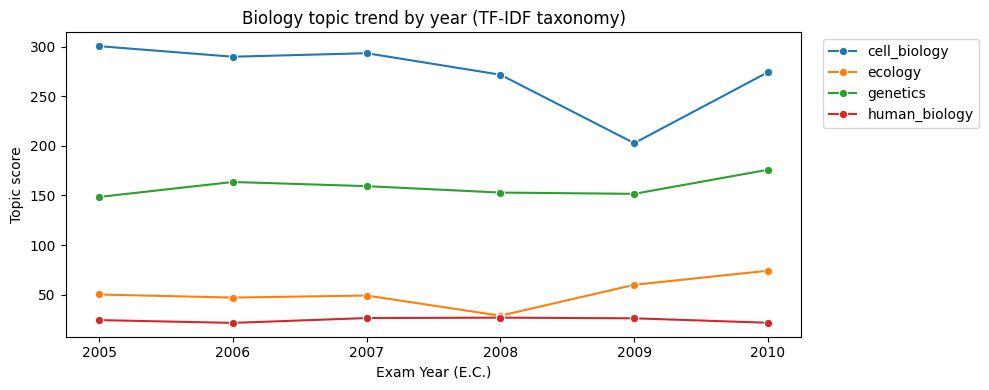

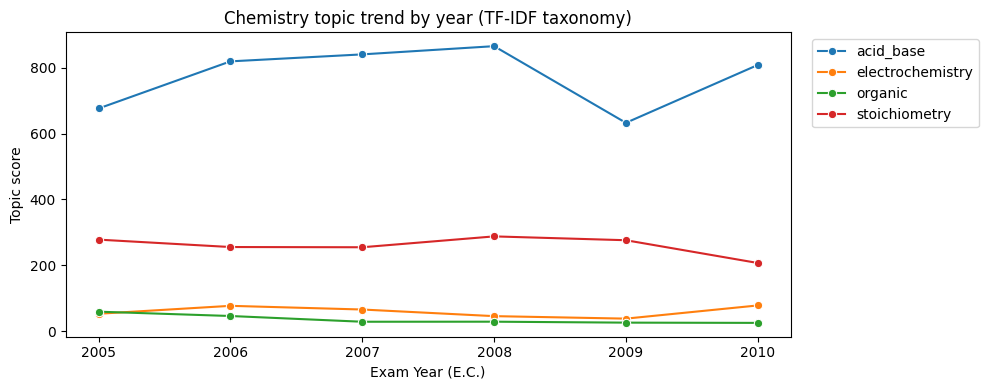

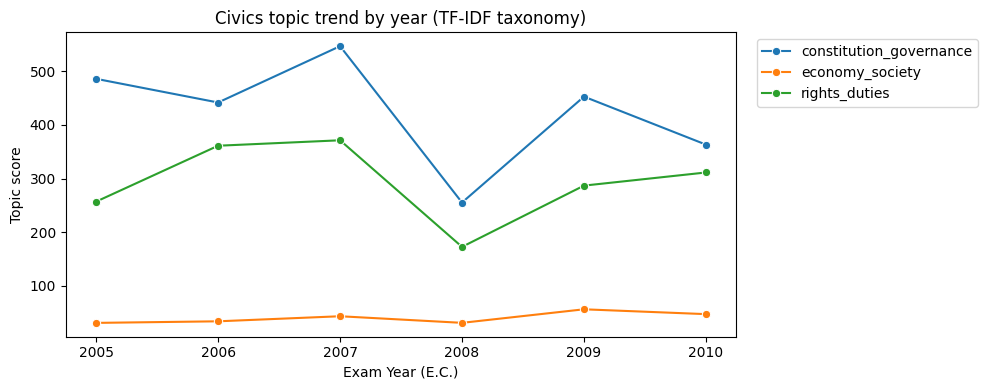

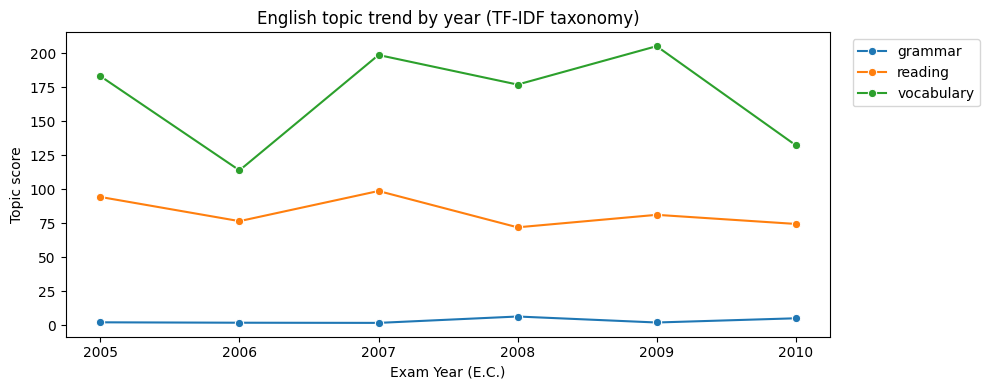

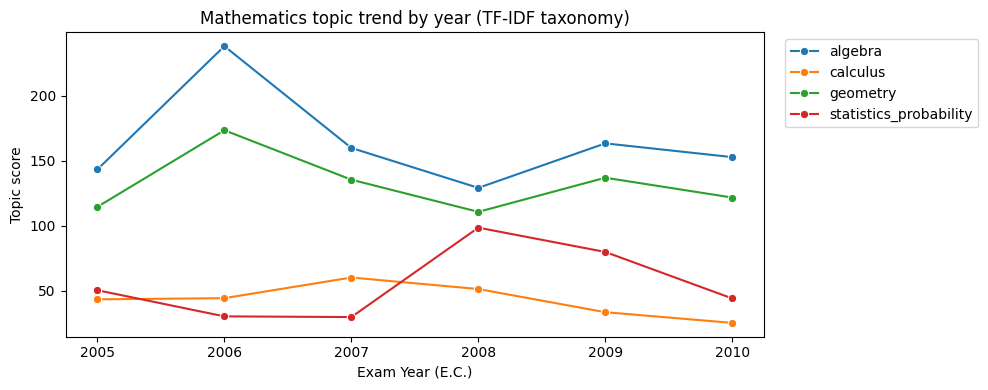

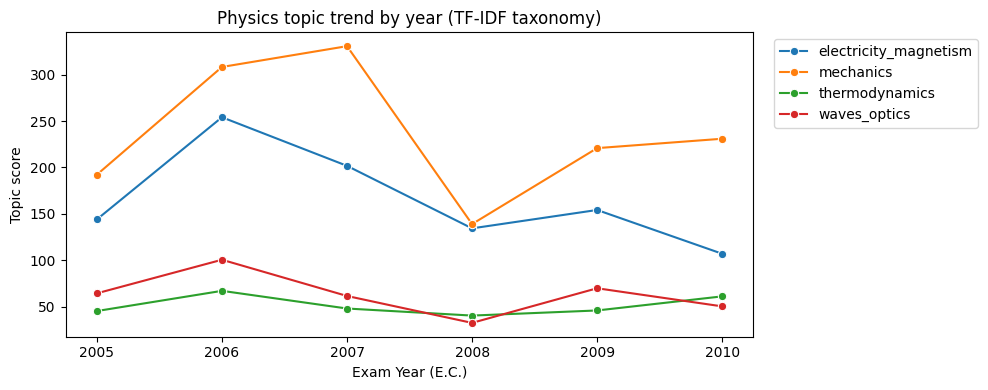

,subject,topic,likely_score,confidence,recent,trend,cyclical,stability
0,biology,cell_biology,0.6267,0.7,1.0000,0.2014,0.2715,0.6604
1,biology,genetics,0.5059,0.7,0.6020,0.3256,0.0000,1.0000
2,biology,ecology,0.3781,0.9,0.1308,1.0000,0.6290,0.0000
3,biology,human_biology,0.3647,0.7,0.0000,0.0000,1.0000,0.8235
4,chemistry,acid_base,0.6449,0.6,1.0000,0.2763,0.0000,0.9484
5,chemistry,stoichiometry,0.5242,0.7,0.3104,0.0000,1.0000,1.0000
6,chemistry,electrochemistry,0.2840,0.7,0.0368,1.0000,0.0000,0.3463
7,chemistry,organic,0.2019,0.7,0.0000,0.2430,0.7666,0.0000
8,civics,constitution_governance,0.8000,0.9,1.0000,0.0000,1.0000,1.0000
9,civics,rights_duties,0.5012,0.9,0.6792,1.0000,0.0000,0.1476


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prediction_model import predict_all, backtest_all, summarize_backtest, EnsembleWeights

question_df = exams_df[exams_df['type'] == 'questions'].copy()
question_df['year_num'] = pd.to_numeric(question_df['year'], errors='coerce')

# Build a hybrid TF-IDF taxonomy per subject from the actual question corpus.
taxonomies = {}
for subject in question_df['subject'].dropna().unique():
    if subject not in TOPIC_RULES:
        continue
    corpus = []
    for qs in question_df.loc[question_df['subject']==subject, 'questions']:
        corpus.extend(qs)
    taxonomies[subject] = build_taxonomy(subject, corpus)

# Score each exam against its subject taxonomy, aggregating per question.
records = []
for _, r in question_df.iterrows():
    tax = taxonomies.get(r['subject'])
    if tax is None:
        continue
    per_topic = {topic: 0.0 for topic in tax.topics}
    questions_or_full = r['questions'] or [r['clean_text']]
    for q in questions_or_full:
        for topic, s in score_text(q, tax).items():
            per_topic[topic] += s
    for topic, score in per_topic.items():
        records.append({
            'subject': r['subject'],
            'year_num': r['year_num'],
            'topic': topic,
            'score': round(score, 3),
        })

trend_df = (pd.DataFrame(records)
              .groupby(['subject','year_num','topic'], as_index=False)['score'].sum())

# Per-year trend charts
for subject in sorted(trend_df['subject'].dropna().unique()):
    sub = trend_df[trend_df['subject']==subject]
    if sub.empty: continue
    plt.figure(figsize=(10,4))
    sns.lineplot(data=sub, x='year_num', y='score', hue='topic', marker='o')
    plt.title(f'{subject.title()} topic trend by year (TF-IDF taxonomy)')
    plt.xlabel('Exam Year (E.C.)')
    plt.ylabel('Topic score')
    plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# --- Ensemble prediction for the next exam year ---
# Components: recent_avg, trend slope, cyclical phase, stability.
# Each component is normalized 0..1 across topics, then weighted.
target_year = float(trend_df['year_num'].max()) + 1
weights = EnsembleWeights()  # 0.40/0.20/0.20/0.20

predictions = predict_all(trend_df, target_year=target_year, weights=weights)
pred_df = pd.DataFrame([p.to_dict() for p in predictions])
# Flatten components for display
if not pred_df.empty:
    comp_df = pred_df['components'].apply(pd.Series)
    pred_df = pd.concat([pred_df.drop(columns=['components','history']), comp_df], axis=1)

next_topics = (pred_df.sort_values(['subject','likely_score'], ascending=[True, False])
                       .groupby('subject').head(5))
next_topics

## Backtest the prediction model

Leave-one-year-out cross-validation: for each historical year (with at least 2 prior years of data), we predict that year using only the preceding years and compare the predicted top-5 topics to the actual top-5.

- **Hit rate**: fraction of actual top-5 topics that appear in the predicted top-5 (closer to 1 is better; 0.7+ is the target).
- **Rank correlation** (Kendall tau): agreement of the predicted vs actual ordering (-1 to 1; >0 means the model ranks correctly).

If hit rate is below ~0.5, the model's predictions for next year shouldn't be trusted yet — more data or better topic detection is needed first.

In [9]:
# Run leave-one-year-out backtest across all subjects.
backtest_results = backtest_all(trend_df, top_k=5, weights=weights)
backtest_df = pd.DataFrame([r.to_dict() for r in backtest_results])

summary = summarize_backtest(backtest_results)
summary_df = (pd.DataFrame(summary).T
                .reset_index()
                .rename(columns={'index': 'subject'})
                .sort_values('mean_hit_rate', ascending=False))

print('Backtest summary (per subject):')
display(summary_df)

print('\nBacktest details (per held-out year):')
display(backtest_df.sort_values(['subject','held_out_year']))

if not summary_df.empty:
    overall_hit = float(summary_df['mean_hit_rate'].mean())
    overall_tau = float(summary_df['mean_rank_correlation'].mean())
    print(f'\nOverall: mean hit rate = {overall_hit:.2f}, mean rank corr = {overall_tau:.2f}')
    if overall_hit < 0.5:
        print('  Hit rate below 0.5 — predictions for next year are unreliable.')
        print('  Likely fixes: improve OCR, fill validation/ground_truth.json, refine TOPIC_RULES.')

Backtest summary (per subject):


,subject,n_folds,mean_hit_rate,mean_rank_correlation
0,biology,4.0,1.0,0.750
1,chemistry,4.0,1.0,0.917
2,civics,4.0,1.0,0.833
3,english,4.0,1.0,0.500
4,mathematics,4.0,1.0,0.750
5,physics,4.0,1.0,0.750



Backtest details (per held-out year):


,subject,held_out_year,top_k,predicted,actual,hit_rate,rank_correlation
0,biology,2007,5,"[cell_biology, genetics, ecology, human_biology]","[cell_biology, genetics, ecology, human_biology]",1.0,1.000
1,biology,2008,5,"[cell_biology, genetics, ecology, human_biology]","[cell_biology, genetics, ecology, human_biology]",1.0,1.000
2,biology,2009,5,"[cell_biology, genetics, human_biology, ecology]","[cell_biology, genetics, ecology, human_biology]",1.0,0.667
3,biology,2010,5,"[genetics, cell_biology, human_biology, ecology]","[cell_biology, genetics, ecology, human_biology]",1.0,0.333
4,chemistry,2007,5,"[acid_base, stoichiometry, electrochemistry, o...","[acid_base, stoichiometry, electrochemistry, o...",1.0,1.000
5,chemistry,2008,5,"[acid_base, stoichiometry, electrochemistry, o...","[acid_base, stoichiometry, electrochemistry, o...",1.0,1.000
6,chemistry,2009,5,"[acid_base, stoichiometry, organic, electroche...","[acid_base, stoichiometry, electrochemistry, o...",1.0,0.667
7,chemistry,2010,5,"[acid_base, stoichiometry, electrochemistry, o...","[acid_base, stoichiometry, electrochemistry, o...",1.0,1.000
8,civics,2007,5,"[constitution_governance, rights_duties, econo...","[constitution_governance, rights_duties, econo...",1.0,1.000
9,civics,2008,5,"[constitution_governance, rights_duties, econo...","[constitution_governance, rights_duties, econo...",1.0,1.000



Overall: mean hit rate = 1.00, mean rank corr = 0.75


In [10]:
from datetime import datetime
from student_output import generate_study_guide, save_study_guide, save_html_guide, render_html

# Generate personalized study guides (JSON + HTML) for each subject.
STUDY_GUIDE_DIR = os.path.join(PROJECT_ROOT, 'study_guides')
os.makedirs(STUDY_GUIDE_DIR, exist_ok=True)

guides_summary = []
for subject in sorted(pred_df['subject'].dropna().unique()):
    # Get backtest metrics for this subject (if available)
    backtest_sub = summary_df[summary_df['subject'] == subject]
    backtest_info = None
    if not backtest_sub.empty:
        row = backtest_sub.iloc[0]
        backtest_info = {
            'hit_rate': float(row.get('mean_hit_rate', 0)),
            'rank_correlation': float(row.get('mean_rank_correlation', 0)),
        }

    # Generate study guide
    guide = generate_study_guide(
        subject=subject,
        exam_year=int(target_year),
        predictions_df=pred_df,
        trend_df=trend_df,
        backtest_result=backtest_info,
        generated_at=datetime.now().isoformat()[:10],
        exams_df=exams_df,
    )

    # Save JSON
    json_path = save_study_guide(guide, STUDY_GUIDE_DIR)

    # Render and save HTML
    html_content = render_html(guide)
    html_path = save_html_guide(guide, html_content, STUDY_GUIDE_DIR)

    guides_summary.append({
        'subject': subject,
        'topics': len(guide.topics),
        'json': os.path.basename(json_path),
        'html': os.path.basename(html_path),
    })

guides_df = pd.DataFrame(guides_summary)
print('Study guides generated:')
display(guides_df)
print(f'\nSaved to: {STUDY_GUIDE_DIR}')
print('\nStudents can now download the JSON or open the HTML in a browser.')


Study guides generated:


,subject,topics,json,html
0,biology,4,biology_2011_study_guide.json,biology_2011_study_guide.html
1,chemistry,4,chemistry_2011_study_guide.json,chemistry_2011_study_guide.html
2,civics,3,civics_2011_study_guide.json,civics_2011_study_guide.html
3,english,3,english_2011_study_guide.json,english_2011_study_guide.html
4,mathematics,4,mathematics_2011_study_guide.json,mathematics_2011_study_guide.html
5,physics,4,physics_2011_study_guide.json,physics_2011_study_guide.html



Saved to: /content/drive/MyDrive/ethiopian_exam_project/study_guides

Students can now download the JSON or open the HTML in a browser.


## Generate student study guides

For each subject, create a personalized study plan that shows:
- **Ranked topics** by likelihood and confidence
- **Why each topic**: historical frequency, trend, cyclical phase
- **Textbook links** (Grades 11 & 12)
- **Study time estimates**
- **Backtest metrics**: proof that the model works (or doesn't)

Output: JSON (machine-readable) + HTML (browser-friendly).

## Next steps for your AI model
- Use `pattern_summary.csv` to identify repeated concepts by subject.
- Train a text classifier on `text_full` with labels like subject/year/type.
- Extract question blocks (split by numbering) and train a topic model to detect recurring question forms.
- Build a study guide from top recurring keywords + question templates.

## Use textbook links in the workflow
This cell downloads the linked Grade 11/12 textbooks and builds a simple topic-reference table to align exam topics with textbook coverage.

In [11]:
TEXTBOOK_DIR = os.path.join(PROJECT_ROOT, 'textbooks')
os.makedirs(TEXTBOOK_DIR, exist_ok=True)

import json

# Load the new textbook links from the provided JSON
with open('/content/download_links.json', 'r') as f:
    new_links_data = json.load(f)

TEXTBOOK_LINKS = []
for grade_level, subjects_data in new_links_data.items():
    # Extract grade number from 'Grade 11', 'Grade 12'
    grade_num = 'g' + grade_level.split(' ')[1]
    for subject, books in subjects_data.items():
        for book_info in books:
            if book_info.get('download_url'):
                # The subject name in the JSON is 'maths', but in the rest of the notebook it's 'mathematics'
                # Adjusting it here for consistency.
                adjusted_subject = 'mathematics' if subject == 'maths' else subject
                TEXTBOOK_LINKS.append((grade_num, adjusted_subject, book_info['download_url']))

def download_textbooks(links):
    rows=[]
    for grade, subject, url in links:
        fname=f'{grade}_{subject}.pdf'
        fpath=os.path.join(TEXTBOOK_DIR,fname)
        if not os.path.exists(fpath):
            ok=download_file(url,fpath,max_retries=2)
            status='downloaded' if ok else 'failed'
        else:
            status='already_exists'
        rows.append({'grade':grade,'subject':subject,'file':fpath,'status':status})
    return pd.DataFrame(rows)

textbook_download_report = download_textbooks(TEXTBOOK_LINKS)
display(textbook_download_report)

,grade,subject,file,status
0,g11,biology,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
1,g11,biology,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
2,g11,chemistry,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
3,g11,chemistry,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
4,g11,english,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
5,g11,english,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
6,g11,mathematics,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
7,g11,mathematics,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
8,g11,physics,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists
9,g11,physics,/content/drive/MyDrive/ethiopian_exam_project/...,already_exists


In [12]:
# OCR textbooks and map topic coverage so exam trends can be aligned to chapters/concepts.
# Uses the same TF-IDF taxonomy as the exam scoring, so textbook and exam scores
# are directly comparable.

# Prefer pdfplumber for selectable PDFs, fall back to PyPDF2, then OCR.
try:
    import pdfplumber
    _HAS_PDFPLUMBER = True
except Exception:
    _HAS_PDFPLUMBER = False
import PyPDF2  # Import PyPDF2 for direct text extraction

def extract_textbook_text(pdf_path):
    # Create a unique filename for the extracted text
    filename_base = os.path.basename(pdf_path).replace('.pdf', '')
    txt_filename = f"{filename_base}.txt"

    # Determine the output directory for the extracted text
    grade, subject = filename_base.split('_', 1)
    subject_extracted_dir = os.path.join(TEXTBOOK_EXTRACTED_DIR, grade, subject)
    os.makedirs(subject_extracted_dir, exist_ok=True)
    txt_path = os.path.join(subject_extracted_dir, txt_filename)

    if os.path.exists(txt_path):
        with open(txt_path, 'r', encoding='utf-8') as f:
            print(f'Loading text for {os.path.basename(pdf_path)} from cache.')
            return f.read()

    # --- Try direct text extraction first (pdfplumber -> PyPDF2) ---
    direct_extracted_full_text = ''
    if _HAS_PDFPLUMBER:
        try:
            with pdfplumber.open(pdf_path) as pdf:
                pages = [p.extract_text() for p in pdf.pages]
            direct_extracted_full_text = clean_question_text(' ' .join([t for t in pages if t]))
            if direct_extracted_full_text.strip():
                print(f'Directly extracted text for {os.path.basename(pdf_path)} (pdfplumber).')
                with open(txt_path, 'w', encoding='utf-8') as f:
                    f.write(direct_extracted_full_text)
                return direct_extracted_full_text
            else:
                print(f'pdfplumber extraction yielded little text; falling back to PyPDF2/OCR.')
        except Exception as e:
            print(f'pdfplumber extraction failed for {os.path.basename(pdf_path)}: {e}; falling back.')
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            extracted_text_parts = []
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                page_text = page.extract_text()
                if page_text:  # Only add if text is found on the page
                    extracted_text_parts.append(page_text)

            direct_extracted_full_text = clean_question_text(' ' .join(extracted_text_parts))
            if direct_extracted_full_text.strip():
                print(f'Directly extracted text for {os.path.basename(pdf_path)} (PyPDF2).')
                with open(txt_path, 'w', encoding='utf-8') as f:
                    f.write(direct_extracted_full_text)
                return direct_extracted_full_text
            else:
                print(f'Direct extraction for {os.path.basename(pdf_path)} yielded little text; falling back to OCR.')
    except Exception as e:
        print(f'Error during direct PDF text extraction for {os.path.basename(pdf_path)}: {e}; falling back to OCR.')

    # --- Fallback to OCR if direct extraction failed or yielded little text ---
    print(f'Performing OCR for {os.path.basename(pdf_path)}...')
    tmp = tempfile.mkdtemp(prefix='tb_ocr_')
    try:
        imgs = pdf_to_images(pdf_path, tmp, dpi=150)  # Use 150 DPI for faster OCR

        def process_img(args):
            idx, img = args
            try:
                t, _ = extract_text_from_image(img)
                return idx, t
            finally:
                try:
                    os.remove(img)
                except OSError:
                    pass

        max_workers = min(len(imgs), os.cpu_count() or 4)
        if max_workers > 1:
            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                res = list(executor.map(process_img, enumerate(imgs)))
        else:
            res = [process_img((idx, img)) for idx, img in enumerate(imgs)]

        res = sorted(res, key=lambda x: x[0])
        parts = [r[1] for r in res]
        text_full = clean_question_text(' ' .join(parts))

        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(text_full)
        return text_full
    finally:
        for f in os.listdir(tmp):
            fp = os.path.join(tmp, f)
            if os.path.isfile(fp):
                os.remove(fp)
        os.rmdir(tmp)

tb_rows = []
for _, r in textbook_download_report.iterrows():
    if r['status'] == 'failed' or r['file'] is None:  # Added check for None file path
        continue
    tax = taxonomies.get(r['subject'])
    if tax is None:
        continue
    tb_text = extract_textbook_text(r['file'])
    if not tb_text:  # Skip if no text was extracted (e.g., blank PDF or OCR failed)
        print(f"Skipping {r['file']} due to empty extracted text.")
        continue
    for topic, s in score_text(tb_text, tax).items():
        tb_rows.append({
            'grade': r['grade'],
            'subject': r['subject'],
            'topic': topic,
            'textbook_score': s,
        })

# Aggregate across curriculum variants (old+new) so each (grade,subject,topic)
# yields a single textbook score; otherwise the merge multiplies prediction rows.
textbook_topic_df = (pd.DataFrame(tb_rows)
                       .groupby(['grade', 'subject', 'topic'], as_index=False)['textbook_score']
                       .sum())

# Pivot so g11 and g12 scores sit side-by-side instead of duplicating rows.
textbook_wide = (textbook_topic_df.pivot_table(index=['subject', 'topic'],
                                               columns='grade',
                                               values='textbook_score',
                                               fill_value=0)
                                  .add_prefix('textbook_score_')
                                  .reset_index())

aligned = (next_topics.merge(textbook_wide, on=['subject', 'topic'], how='left')
                       .fillna(0)
                       .sort_values(['subject', 'likely_score'], ascending=[True, False]))
aligned.head(20)


Loading text for g11_biology.pdf from cache.
Loading text for g11_biology.pdf from cache.
Loading text for g11_chemistry.pdf from cache.
Loading text for g11_chemistry.pdf from cache.
Loading text for g11_english.pdf from cache.
Loading text for g11_english.pdf from cache.
Loading text for g11_mathematics.pdf from cache.
Loading text for g11_mathematics.pdf from cache.
Loading text for g11_physics.pdf from cache.
Loading text for g11_physics.pdf from cache.
Loading text for g12_biology.pdf from cache.
Loading text for g12_biology.pdf from cache.
Loading text for g12_chemistry.pdf from cache.
Loading text for g12_chemistry.pdf from cache.
Loading text for g12_english.pdf from cache.
Loading text for g12_english.pdf from cache.
Loading text for g12_mathematics.pdf from cache.
Loading text for g12_mathematics.pdf from cache.
Loading text for g12_physics.pdf from cache.
Loading text for g12_physics.pdf from cache.


,subject,topic,likely_score,confidence,recent,trend,cyclical,stability,grade,textbook_score
0,biology,cell_biology,0.6267,0.7,1.0000,0.2014,0.2715,0.6604,g11,5891.024
1,biology,cell_biology,0.6267,0.7,1.0000,0.2014,0.2715,0.6604,g11,5891.024
2,biology,cell_biology,0.6267,0.7,1.0000,0.2014,0.2715,0.6604,g12,105.445
3,biology,cell_biology,0.6267,0.7,1.0000,0.2014,0.2715,0.6604,g12,105.445
4,biology,genetics,0.5059,0.7,0.6020,0.3256,0.0000,1.0000,g11,5610.469
5,biology,genetics,0.5059,0.7,0.6020,0.3256,0.0000,1.0000,g11,5610.469
6,biology,genetics,0.5059,0.7,0.6020,0.3256,0.0000,1.0000,g12,48.634
7,biology,genetics,0.5059,0.7,0.6020,0.3256,0.0000,1.0000,g12,48.634
8,biology,ecology,0.3781,0.9,0.1308,1.0000,0.6290,0.0000,g11,2082.837
9,biology,ecology,0.3781,0.9,0.1308,1.0000,0.6290,0.0000,g11,2082.837


## Grade 11 & 12 textbook links (Ethiopia Learning)
Use these as source materials for topic mapping and revision datasets:

### Grade 12
- Biology: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_BIOLOGY_CURRICULUM_Language_ENGLISH_Retrieved_20150101.pdf
- Civics: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_CIVICS_Language_ENGLISH_Retrieved_20150101.pdf
- Chemistry: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_CHEMISTRY_Language_ENGLISH_Retrieved_20150101.pdf
- English: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_ENGLISH_Language_ENGLISH_Retrieved_20200601.pdf
- Math: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_MATH_Language_ENGLISH_Retrieved_20200601.pdf
- Physics: https://files.ethiopialearning.com/textbooks/Grade%2012/Grade_12_Subject_PHYSICS_Language_ENGLISH_Retrieved_20200601.pdf

### Grade 11
- Physics: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_PHYSICS_Language_ENGLISH_Retrieved_20200601.pdf
- Math: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_MATH_Language_ENGLISH_Retrieved_20200601.pdf
- English: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_ENGLISH_Language_ENGLISH_Retrieved_20150101.pdf
- Civics: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_CIVICS_Language_ENGLISH_Retrieved_20150101.pdf
- Chemistry: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_CHEMISTRY_Language_ENGLISH_Retrieved_20150101.pdf
- Biology: https://files.ethiopialearning.com/textbooks/Grade%2011/Grade_11_Subject_BIOLOGY_CURRICULUM_Language_ENGLISH_To_Grade_12_Retrieved_20150101.pdf
